# 0.1 — Espacios de probabilidad, variables aleatorias y convergencia

## Motivación

Todo el pricing moderno de derivados se reduce, en el fondo, a calcular una esperanza bajo una medida de probabilidad: el precio de una opción es $\mathbb{E}^{\mathbb{Q}}[e^{-rT}\,\text{payoff}]$, un estimador Monte Carlo es una media muestral, y un error estándar es una desviación típica dividida por $\sqrt{n}$. Antes de derivar Black-Scholes o simular una SDE necesitamos el lenguaje formal que sostiene todo esto: qué es un espacio de probabilidad, qué es exactamente una variable aleatoria, en qué sentidos puede "converger" una secuencia de v.a. y por qué el promedio de una simulación se estabiliza y se vuelve gaussiano.

Este notebook es la **plantilla de referencia** del currículum: fija la estructura (teoría → demo numérica → validación → referencias) que replican los 48 notebooks siguientes. Cubrimos: (i) el espacio $(\Omega, \mathcal{F}, \mathbb{P})$ y la noción de variable aleatoria; (ii) esperanza, momentos y las desigualdades de Markov/Chebyshev; (iii) modos de convergencia y los dos teoremas límite —Ley de los Grandes Números (LLN) y Teorema Central del Límite (CLT)— que justifican por qué Monte Carlo funciona.

## 1. Espacio de probabilidad y variables aleatorias

### 1.1 El espacio $(\Omega, \mathcal{F}, \mathbb{P})$

**Definición (espacio de probabilidad).** Un espacio de probabilidad es una terna $(\Omega, \mathcal{F}, \mathbb{P})$ donde:

- $\Omega$ es el **espacio muestral**: el conjunto de todos los resultados posibles de un experimento aleatorio (una trayectoria de precios, una secuencia de rendimientos, etc.).
- $\mathcal{F} \subseteq 2^{\Omega}$ es una **σ-álgebra**: una colección de subconjuntos de $\Omega$ (los *eventos*) cerrada bajo complemento y uniones numerables:
$$
\Omega \in \mathcal{F}, \qquad A \in \mathcal{F} \implies A^c \in \mathcal{F}, \qquad A_1, A_2, \dots \in \mathcal{F} \implies \bigcup_{i=1}^{\infty} A_i \in \mathcal{F}.
$$
- $\mathbb{P}: \mathcal{F} \to [0,1]$ es una **medida de probabilidad**: $\mathbb{P}(\Omega) = 1$ y $\mathbb{P}$ es σ-aditiva sobre uniones disjuntas numerables.

La interpretación que usaremos en todo el currículum: $\mathcal{F}$ codifica **información**. Una sub-σ-álgebra $\mathcal{F}_t \subseteq \mathcal{F}$ representa "lo que se sabe hasta el tiempo $t$" — esta idea es la base de la filtración que aparece en 0.2 (esperanza condicional y martingalas) y en todo el cálculo estocástico posterior.

### 1.2 Variables aleatorias

**Definición (variable aleatoria).** Una función $X: \Omega \to \mathbb{R}$ es una variable aleatoria (v.a.) si es $\mathcal{F}$-medible, es decir:
$$
X^{-1}((-\infty, x]) = \{\omega \in \Omega : X(\omega) \le x\} \in \mathcal{F} \quad \forall x \in \mathbb{R}.
$$

La medibilidad es lo que permite preguntar "¿cuál es la probabilidad de que $X \le x$?" — sin ella, el evento correspondiente podría no tener una probabilidad asignada.

### 1.3 Ley, CDF y PDF

La v.a. $X$ induce una medida de probabilidad en $\mathbb{R}$ llamada su **ley** o **distribución**, $\mu_X(B) = \mathbb{P}(X \in B)$. En la práctica trabajamos con dos objetos equivalentes:

**Función de distribución acumulada (CDF):**
$$
F_X(x) = \mathbb{P}(X \le x), \qquad x \in \mathbb{R}.
$$
$F_X$ es no decreciente, continua por la derecha, con $\lim_{x \to -\infty} F_X(x) = 0$ y $\lim_{x \to \infty} F_X(x) = 1$.

**Función de densidad (PDF),** cuando $X$ es continua (i.e. $F_X$ es absolutamente continua):
$$
f_X(x) = \frac{dF_X}{dx}(x), \qquad F_X(x) = \int_{-\infty}^{x} f_X(u)\,du.
$$

Trabajaremos extensivamente con la distribución **exponencial**, que modela tiempos de espera y aparece como caso de estudio en las demos numéricas de este notebook:
$$
f_X(x) = \lambda e^{-\lambda x} \mathbb{1}_{\{x \ge 0\}}, \qquad \mathbb{E}[X] = \frac{1}{\lambda}, \qquad \text{Var}(X) = \frac{1}{\lambda^2}.
$$

## 2. Esperanza, momentos y desigualdades de concentración

### 2.1 Esperanza como integral de Lebesgue

**Definición (esperanza).** Para una v.a. $X$ con densidad $f_X$, la esperanza es
$$
\mathbb{E}[X] = \int_{\Omega} X(\omega)\, d\mathbb{P}(\omega) = \int_{-\infty}^{\infty} x\, f_X(x)\, dx,
$$
siempre que $\mathbb{E}[|X|] < \infty$. La primera igualdad es la definición general (integral de Lebesgue respecto a $\mathbb{P}$); la segunda es el caso continuo, obtenido por el teorema de cambio de variable. Esta formulación es la que generaliza sin fricción a martingalas y a cambios de medida (Girsanov, 01.5): $\mathbb{E}^{\mathbb{Q}}[X] = \int X \, \frac{d\mathbb{Q}}{d\mathbb{P}}\, d\mathbb{P}$.

### 2.2 Momentos

El **momento de orden $k$** es $\mathbb{E}[X^k]$; el **momento central de orden $k$** es $\mathbb{E}[(X - \mathbb{E}[X])^k]$. El caso $k=2$ define la **varianza**:
$$
\text{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2, \qquad \sigma_X = \sqrt{\text{Var}(X)}.
$$

### 2.3 Desigualdad de Markov

**Proposición (Markov).** Si $X \ge 0$ y $a > 0$, entonces
$$
\mathbb{P}(X \ge a) \le \frac{\mathbb{E}[X]}{a}.
$$

*Demostración.* $\mathbb{E}[X] \ge \mathbb{E}[X \, \mathbb{1}_{\{X \ge a\}}] \ge \mathbb{E}[a \, \mathbb{1}_{\{X \ge a\}}] = a\, \mathbb{P}(X \ge a)$. $\blacksquare$

### 2.4 Desigualdad de Chebyshev

**Proposición (Chebyshev).** Si $X$ tiene varianza finita $\sigma_X^2$ y $k > 0$, entonces
$$
\mathbb{P}(|X - \mathbb{E}[X]| \ge k\sigma_X) \le \frac{1}{k^2}.
$$

*Demostración.* Sea $Y = (X - \mathbb{E}[X])^2 \ge 0$ y $a = k^2 \sigma_X^2$. Por Markov aplicado a $Y$:
$$
\mathbb{P}(|X - \mathbb{E}[X]| \ge k\sigma_X) = \mathbb{P}(Y \ge k^2\sigma_X^2) \le \frac{\mathbb{E}[Y]}{k^2 \sigma_X^2} = \frac{\sigma_X^2}{k^2 \sigma_X^2} = \frac{1}{k^2}. \quad \blacksquare
$$

Chebyshev es la herramienta más directa para cuantificar *qué tan rápido* se concentra un promedio muestral alrededor de su media — la usaremos en la demo de la sección 4 para acotar la probabilidad de que $\bar{X}_n$ se aleje de $\mu$, y es la base de la prueba elemental de la LLN débil.

## 3. Modos de convergencia y los dos teoremas límite

Sea $(X_n)_{n \ge 1}$ una sucesión de variables aleatorias y $X$ una v.a. límite. Hay cuatro nociones estándar de convergencia, de más fuerte a más débil:

**Convergencia casi segura (a.s.):** $X_n \xrightarrow{\text{a.s.}} X$ si
$$
\mathbb{P}\left(\lim_{n \to \infty} X_n = X\right) = 1.
$$

**Convergencia en probabilidad:** $X_n \xrightarrow{\mathbb{P}} X$ si $\forall \varepsilon > 0$,
$$
\lim_{n \to \infty} \mathbb{P}(|X_n - X| > \varepsilon) = 0.
$$

**Convergencia en $L^p$:** $X_n \xrightarrow{L^p} X$ si
$$
\lim_{n \to \infty} \mathbb{E}[|X_n - X|^p] = 0.
$$

**Convergencia en distribución:** $X_n \xrightarrow{d} X$ si, en todo punto de continuidad $x$ de $F_X$,
$$
\lim_{n \to \infty} F_{X_n}(x) = F_X(x).
$$

**Diagrama de implicaciones** (ninguna flecha se invierte en general):
$$
\text{a.s.} \implies \mathbb{P} \qquad L^p \implies \mathbb{P} \qquad \mathbb{P} \implies d.
$$

Es decir: convergencia casi segura y convergencia en $L^p$ implican convergencia en probabilidad, y esta a su vez implica convergencia en distribución — pero convergencia en distribución es estrictamente la más débil de las cuatro, y en general no implica ninguna de las otras.

### 3.1 Ley Fuerte de los Grandes Números (LLN)

**Teorema (LLN fuerte).** Sean $X_1, X_2, \dots$ i.i.d. con $\mathbb{E}[|X_1|] < \infty$ y $\mathbb{E}[X_1] = \mu$. Sea $\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$. Entonces
$$
\bar{X}_n \xrightarrow{\text{a.s.}} \mu \quad \text{cuando } n \to \infty.
$$

No demostramos este resultado aquí (ver Williams, cap. 7); la demo numérica de la sección 5 lo ilustra por simulación.

### 3.2 Teorema Central del Límite (CLT)

**Teorema (CLT).** Sean $X_1, X_2, \dots$ i.i.d. con $\mathbb{E}[X_1] = \mu$ y $\text{Var}(X_1) = \sigma^2 < \infty$. Entonces
$$
\sqrt{n}\,\frac{\bar{X}_n - \mu}{\sigma} \xrightarrow{d} \mathcal{N}(0, 1) \quad \text{cuando } n \to \infty.
$$

El CLT es la razón por la que un intervalo de confianza Monte Carlo tiene la forma $\bar{X}_n \pm 1.96\, \sigma / \sqrt{n}$ (04.1): la distribución del error del estimador es aproximadamente gaussiana **sin importar la distribución de $X_1$**, siempre que tenga varianza finita.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

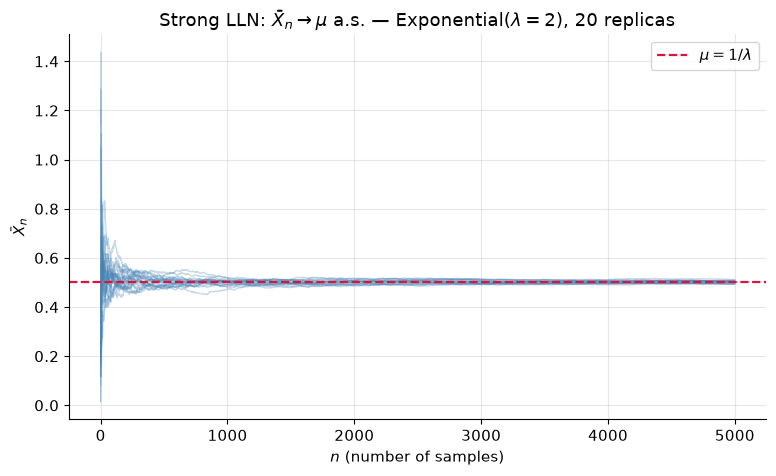

In [2]:
# LLN demo: cumulative means of Exponential(lambda=2) samples, 20 replicas
lam = 2.0
mu = 1 / lam

n_lln = 5_000
n_reps_lln = 20

lln_samples = rng.exponential(scale=1 / lam, size=(n_reps_lln, n_lln))
cum_means = np.cumsum(lln_samples, axis=1) / np.arange(1, n_lln + 1)

fig, ax = plt.subplots()
for i in range(n_reps_lln):
    ax.plot(cum_means[i], color="steelblue", alpha=0.3, linewidth=0.9)
ax.axhline(mu, color="crimson", linestyle="--", linewidth=1.6, label=r"$\mu = 1/\lambda$")
ax.set_xlabel("$n$ (number of samples)")
ax.set_ylabel(r"$\bar{X}_n$")
ax.set_title(r"Strong LLN: $\bar{X}_n \to \mu$ a.s. — Exponential($\lambda=2$), 20 replicas")
ax.legend()
plt.show()

Cada trayectoria azul es la media acumulada $\bar{X}_n$ de una réplica independiente de 5 000 exponenciales. Todas arrancan dispersas (con poca información, $\bar{X}_n$ es ruidosa) y convergen hacia la línea roja $\mu = 1/\lambda = 0.5$ conforme $n$ crece — la ilustración empírica de la convergencia casi segura: **cada** trayectoria individual se estabiliza en el límite, no solo el promedio sobre réplicas.

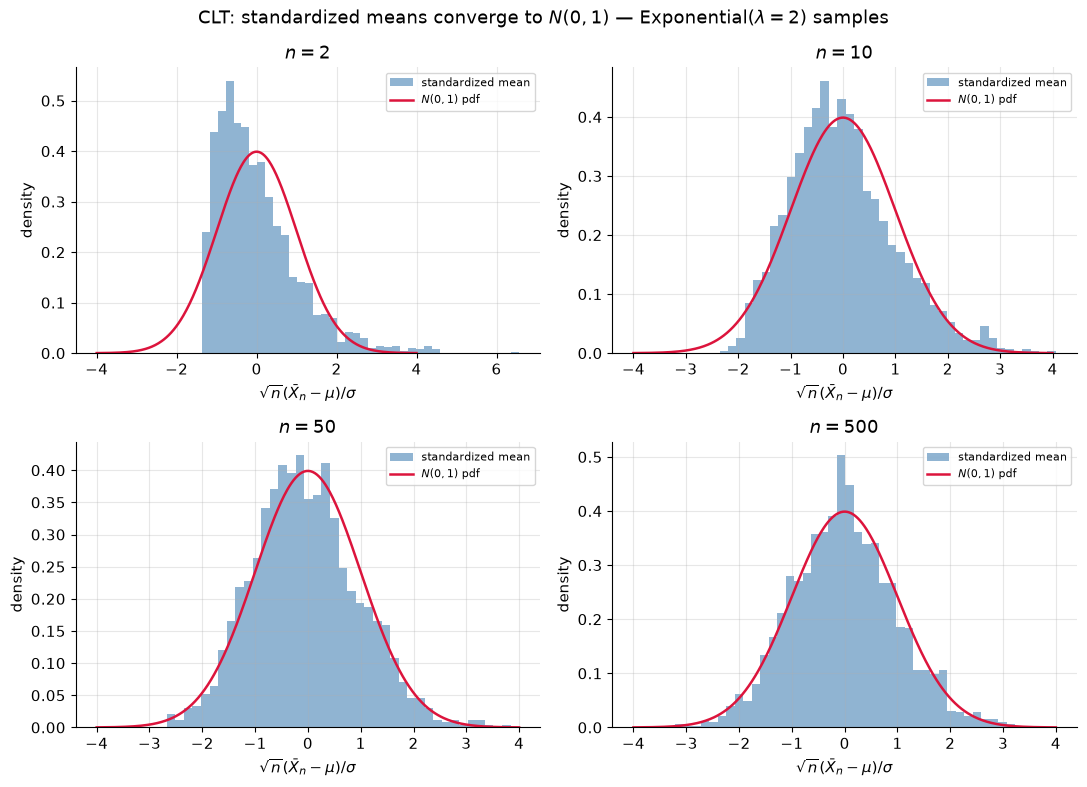

In [3]:
# CLT demo: distribution of sqrt(n)*(X_bar - mu)/sigma for n in {2, 10, 50, 500}
sigma = 1 / lam
n_list = [2, 10, 50, 500]
n_reps_clt = 2_000

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
x_grid = np.linspace(-4, 4, 400)
normal_pdf = stats.norm.pdf(x_grid)

for ax, n in zip(axes.ravel(), n_list):
    samples = rng.exponential(scale=1 / lam, size=(n_reps_clt, n))
    means = samples.mean(axis=1)
    z = np.sqrt(n) * (means - mu) / sigma

    ax.hist(z, bins=40, density=True, color="steelblue", alpha=0.6, label="standardized mean")
    ax.plot(x_grid, normal_pdf, color="crimson", linewidth=1.8, label=r"$N(0,1)$ pdf")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel(r"$\sqrt{n}(\bar{X}_n - \mu)/\sigma$")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

fig.suptitle(r"CLT: standardized means converge to $N(0,1)$ — Exponential($\lambda=2$) samples")
fig.tight_layout()
plt.show()

La exponencial es fuertemente asimétrica ($n=2$: el histograma todavía muestra la cola derecha pesada del origen), pero conforme $n$ crece la distribución de la media estandarizada pierde asimetría y se pega a la densidad $N(0,1)$ — para $n=500$ son prácticamente indistinguibles. Este es el CLT en acción: **la forma de la distribución original deja de importar** una vez que estandarizamos el promedio de suficientes muestras.

  k | empirical P(|X_bar-mu|>=k*sigma) |  Chebyshev bound 1/k^2
-----------------------------------------------------------------
  1 |                           0.3204 |                 1.0000
  2 |                           0.0514 |                 0.2500
  3 |                           0.0058 |                 0.1111
  4 |                           0.0004 |                 0.0625


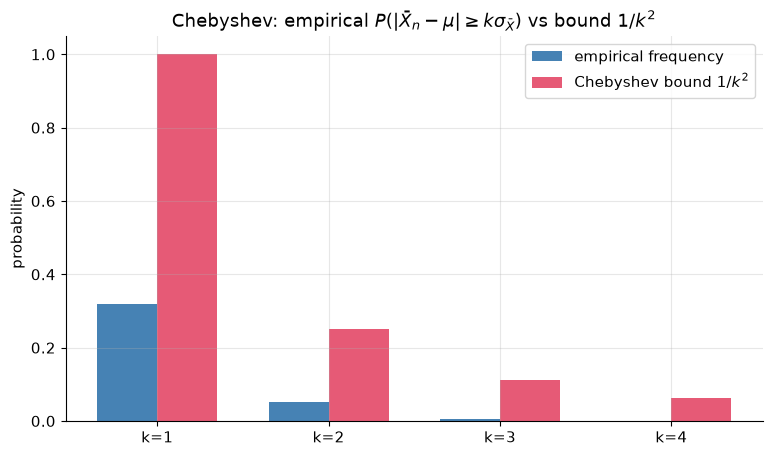

In [4]:
# Chebyshev demo: empirical frequency of |X_bar - mu| >= k*sigma_Xbar vs bound 1/k^2
n_cheb = 30
n_reps_cheb = 5_000

cheb_samples = rng.exponential(scale=1 / lam, size=(n_reps_cheb, n_cheb))
cheb_means = cheb_samples.mean(axis=1)
sigma_xbar = sigma / np.sqrt(n_cheb)

ks = [1, 2, 3, 4]
rows = []
for k in ks:
    empirical_freq = np.mean(np.abs(cheb_means - mu) >= k * sigma_xbar)
    bound = 1 / k**2
    rows.append((k, empirical_freq, bound))

print(f"{'k':>3} | {'empirical P(|X_bar-mu|>=k*sigma)':>32} | {'Chebyshev bound 1/k^2':>22}")
print("-" * 65)
for k, freq, bound in rows:
    print(f"{k:>3} | {freq:>32.4f} | {bound:>22.4f}")

empirical_freqs = [r[1] for r in rows]
bounds = [r[2] for r in rows]
x_pos = np.arange(len(ks))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x_pos - width / 2, empirical_freqs, width, label="empirical frequency", color="steelblue")
ax.bar(x_pos + width / 2, bounds, width, label=r"Chebyshev bound $1/k^2$", color="crimson", alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_ylabel("probability")
ax.set_title(r"Chebyshev: empirical $P(|\bar{X}_n-\mu|\geq k\sigma_{\bar{X}})$ vs bound $1/k^2$")
ax.legend()
plt.show()

En los cuatro casos la frecuencia empírica queda muy por debajo de la cota $1/k^2$ — Chebyshev es una desigualdad genérica (válida para *cualquier* distribución con varianza finita) y por eso es conservadora: no explota que $\bar{X}_{30}$ ya es aproximadamente gaussiana por el CLT, donde $\mathbb{P}(|Z|\ge k)$ decae exponencialmente en vez de como $1/k^2$. La cota es útil precisamente cuando no queremos o no podemos asumir normalidad.

## 4. Validación

Este notebook no involucra pricing, así que no hay una comparación contra QuantLib como en los notebooks de módulos posteriores. En su lugar, la validación es **estadística**: si el CLT es correcto, las medias estandarizadas de muestras exponenciales deben ser indistinguibles de una $N(0,1)$ para $n$ suficientemente grande. Usamos el test de Kolmogorov-Smirnov de una muestra (`scipy.stats.kstest`) sobre 500 medias estandarizadas ($n=50$ observaciones cada una) contra la CDF normal estándar.

**Nota sobre la convención de $n$:** aquí `n` sigue jugando el rol de tamaño de muestra por media (igual que en la demo CLT de la sección anterior), fijado en $n=50$; las "500" no son el tamaño de una sola muestra sino el número de medias estandarizadas independientes que alimentan el test — el K-S necesita muchas observaciones independientes de la estadística $\sqrt{n}(\bar{X}_n-\mu)/\sigma$ para tener poder estadístico, no una única media calculada con $n$ grande.

In [5]:
# Validation: K-S test of standardized means (n=500 replicates) against N(0,1)
n_size = 50
n_reps_val = 500

val_samples = rng.exponential(scale=1 / lam, size=(n_reps_val, n_size))
val_means = val_samples.mean(axis=1)
z_val = np.sqrt(n_size) * (val_means - mu) / sigma

ks_stat, p_value = stats.kstest(z_val, "norm")
print(f"K-S statistic = {ks_stat:.4f}")
print(f"p-value       = {p_value:.4f}")

assert p_value > 0.05, "K-S test rejects H0: standardized means are not N(0,1)-like at alpha=0.05"
print("Validation passed: cannot reject H0 (standardized means ~ N(0,1)) at alpha=0.05.")

K-S statistic = 0.0320
p-value       = 0.6742
Validation passed: cannot reject H0 (standardized means ~ N(0,1)) at alpha=0.05.


## Referencias

- Shreve, S. (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*, cap. 1–2.
- Williams, D. (1991). *Probability with Martingales*. Cambridge University Press.
- Jacod, J. & Protter, P. (2004). *Probability Essentials*, 2nd ed. Springer.